<a href="https://colab.research.google.com/github/ykim68ncstate/ECE592_GenAI-Introandapplication_Project_ykim68/blob/main/Milestone/Project_Milestone_YujinKim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Milestone: Physics-Grounded Generative HVAC Diagnosis
* **Name/Unity ID:** Yujin Kim / ykim68
* **Course: ECE 592** Gen AI: Intro and Applications
* **Assignements:** Project Milestone


This project develops a physics-grounded generative diagnostic system for analyzing Air Handling Unit (AHU) operations using Building Automation System (BAS) data. A data-driven pipeline is constructed to process time-series sensor data, compute thermodynamically consistent cooling loads, and estimate fan energy consumption.

In [1]:
## import library
import pandas as pd
import numpy as np
from functools import reduce
import matplotlib.pyplot as plt
import os

In [2]:
# load HVAC data files
from google.colab import files
uploaded = files.upload()

Saving AHU-2 AvgMaTmp.xlsx to AHU-2 AvgMaTmp.xlsx
Saving AHU-2 OaFl.xlsx to AHU-2 OaFl.xlsx
Saving AHU-2 OaTmp.xlsx to AHU-2 OaTmp.xlsx
Saving AHU-2 RaTmp1.xlsx to AHU-2 RaTmp1.xlsx
Saving AHU-2 RaTmp2.xlsx to AHU-2 RaTmp2.xlsx
Saving AHU-2 RaTmp3.xlsx to AHU-2 RaTmp3.xlsx
Saving AHU-2 SaFanASpd.xlsx to AHU-2 SaFanASpd.xlsx
Saving AHU-2 SaFanBSpd.xlsx to AHU-2 SaFanBSpd.xlsx
Saving AHU-2 SaFanCSpd.xlsx to AHU-2 SaFanCSpd.xlsx
Saving AHU-2 SaFanDSpd.xlsx to AHU-2 SaFanDSpd.xlsx
Saving AHU-2 SaFanESpd.xlsx to AHU-2 SaFanESpd.xlsx
Saving AHU-2 SaFanFSpd.xlsx to AHU-2 SaFanFSpd.xlsx
Saving AHU-2 SaFl.xlsx to AHU-2 SaFl.xlsx
Saving AHU-2 SaStPr.xlsx to AHU-2 SaStPr.xlsx
Saving AHU-2 SaTmp.xlsx to AHU-2 SaTmp.xlsx


## Layer 1. Data & Physics Engine
BAS data from an AHU is processed to compute key operational indicators:
* Mixed Air Temperature (MA)
* Supply Air Temperature (SA)
* Airflow (CFM)
* Cooling Load (BTu/h, kW thermal)
* Cooling Energy (kWh thermal)
* Fan Power(kW, estimated)
* Fan Energy (kWh)

### (1) Data Pre-processing


In [3]:
dfs = {}

for filename in uploaded.keys():
    if filename.endswith(".xlsx"):
       df = pd.read_excel(filename)
    elif filename.endswith(".csv"):
       try:
         df = pd.read_csv(filename, encoding="utf-8")
       except:
         df = pd.read_csv(filename, encoding="latin1")
    else:
        print(f"Skipping unsupported file: {filename}")
        continue

    dfs[filename] = df
    print(f"{filename} loaded: {df.shape}")


AHU-2 AvgMaTmp.xlsx loaded: (34366, 2)
AHU-2 OaFl.xlsx loaded: (34387, 2)
AHU-2 OaTmp.xlsx loaded: (34393, 2)
AHU-2 RaTmp1.xlsx loaded: (34393, 2)
AHU-2 RaTmp2.xlsx loaded: (34391, 2)
AHU-2 RaTmp3.xlsx loaded: (34393, 2)
AHU-2 SaFanASpd.xlsx loaded: (34387, 2)
AHU-2 SaFanBSpd.xlsx loaded: (34394, 2)
AHU-2 SaFanCSpd.xlsx loaded: (34390, 2)
AHU-2 SaFanDSpd.xlsx loaded: (34391, 2)
AHU-2 SaFanESpd.xlsx loaded: (34395, 2)
AHU-2 SaFanFSpd.xlsx loaded: (34392, 2)
AHU-2 SaFl.xlsx loaded: (34385, 2)
AHU-2 SaStPr.xlsx loaded: (34392, 2)
AHU-2 SaTmp.xlsx loaded: (34391, 2)


In [4]:
for name, df in dfs.items():
    print("===", name, "===")
    print(df.head())
    print(df.columns.tolist())
    print()

=== AHU-2 AvgMaTmp.xlsx ===
              Time stamp  AHU-2 AvgMaTmp
0  10/25/2025 6:50:49 PM       66.730759
1  10/25/2025 6:35:49 PM       66.869202
2  10/25/2025 6:20:49 PM       67.076904
3  10/25/2025 6:05:49 PM       67.215378
4  10/25/2025 5:50:49 PM       67.423096
['Time stamp', 'AHU-2 AvgMaTmp']

=== AHU-2 OaFl.xlsx ===
               Time stamp  AHU-2 OaFl
0   10/26/2025 1:50:49 AM     11557.0
1   10/26/2025 1:35:49 AM      8833.5
2   10/26/2025 1:20:49 AM     10231.0
3   10/26/2025 1:05:49 AM      5369.0
4  10/26/2025 12:50:49 AM      7514.0
['Time stamp', 'AHU-2 OaFl']

=== AHU-2 OaTmp.xlsx ===
               Time stamp  AHU-2 OaTmp
0   10/26/2025 1:50:49 AM    45.009998
1   10/26/2025 1:35:49 AM    45.139999
2   10/26/2025 1:20:49 AM    45.180000
3   10/26/2025 1:05:49 AM    45.720001
4  10/26/2025 12:50:49 AM    46.259998
['Time stamp', 'AHU-2 OaTmp']

=== AHU-2 RaTmp1.xlsx ===
               Time stamp  AHU-2 RaTmp1
0   10/26/2025 1:50:49 AM     72.615387
1   10/26/2025

In [5]:
cleaned_dfs = []

for filename, df in dfs.items():
    cols = df.columns.tolist()

    time_col = cols[0]
    value_col = cols[1]

    df[time_col] = pd.to_datetime(df[time_col])

    df = df.sort_values(time_col)

    sensor_name = filename.split(".")[0]

    df = df[[time_col, value_col]].rename(columns={
        time_col: "timestamp",
        value_col: sensor_name
    })

    cleaned_dfs.append(df)

/tmp/ipykernel_12027/362647346.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col])
/tmp/ipykernel_12027/362647346.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col])


In [6]:
merged_df = reduce(lambda left, right:pd.merge(left, right, on="timestamp", how="inner"), cleaned_dfs) #merge data
merged_df.head()

,timestamp,AHU-2 AvgMaTmp,AHU-2 OaFl,AHU-2 OaTmp,AHU-2 RaTmp1,AHU-2 RaTmp2,AHU-2 RaTmp3,AHU-2 SaFanASpd,AHU-2 SaFanBSpd,AHU-2 SaFanCSpd,AHU-2 SaFanDSpd,AHU-2 SaFanESpd,AHU-2 SaFanFSpd,AHU-2 SaFl,AHU-2 SaStPr,AHU-2 SaTmp
0,2024-11-01 23:01:13,69.915405,5297.50,65.860001,75.015381,69.107719,70.353859,50.996346,50.996346,50.996346,50.996346,50.996346,50.996346,14409.623047,1.264688,54.892303
1,2024-11-01 23:16:13,69.869209,5440.50,65.879997,74.923088,69.107719,70.353859,49.974602,49.974602,49.974602,49.974602,49.974602,49.974602,13864.597656,1.229687,55.076923
2,2024-11-01 23:31:13,69.823059,3796.00,65.860001,75.107712,69.061523,70.307693,47.374275,47.374275,47.374275,47.374275,47.374275,47.374275,13197.990234,1.110937,55.030796
3,2024-11-01 23:46:13,69.799988,5466.50,65.769997,74.876961,69.107719,70.261566,52.612144,52.612144,52.612144,52.612144,52.612144,52.612144,15122.347656,1.299688,54.984631
4,2024-11-02 00:01:13,69.799988,5229.25,65.980003,75.153870,69.061523,70.261566,48.546005,48.546005,48.546005,48.546005,48.546005,48.546005,13537.583008,1.173750,55.076923


In [7]:
merged_df = merged_df.rename(columns={
    "AHU-2 AvgMaTmp": "MA_T",
    "AHU-2 OaFl": "OA_CFM",
    "AHU-2 SaTmp": "SA_T",
    "AHU-2 SaFl": "SA_CFM",
    "AHU-2 OaTmp": "OA_T",
    "AHU-2 SaStPr": "SA_static_pressure",
    "AHU-2 SaFanASpd": "SF1_speed",
    "AHU-2 SaFanBSpd": "SF2_speed",
    "AHU-2 SaFanCSpd": "SF3_speed",
    "AHU-2 SaFanDSpd": "SF4_speed",
    "AHU-2 SaFanESpd": "SF5_speed",
    "AHU-2 SaFanFSpd": "SF6_speed",
})

In [8]:
merged_df["RA_T"] = merged_df[[
    "AHU-2 RaTmp1",
    "AHU-2 RaTmp2",
    "AHU-2 RaTmp3"
]].mean(axis=1)

In [9]:
merged_df = merged_df.drop(columns=[
    "AHU-2 RaTmp1",
    "AHU-2 RaTmp2",
    "AHU-2 RaTmp3"
])

In [10]:
df["timestamp"] = df["timestamp"].dt.floor("15min")

In [11]:
merged_df.head()

,timestamp,MA_T,OA_CFM,OA_T,SF1_speed,SF2_speed,SF3_speed,SF4_speed,SF5_speed,SF6_speed,SA_CFM,SA_static_pressure,SA_T,RA_T
0,2024-11-01 23:01:13,69.915405,5297.50,65.860001,50.996346,50.996346,50.996346,50.996346,50.996346,50.996346,14409.623047,1.264688,54.892303,71.492320
1,2024-11-01 23:16:13,69.869209,5440.50,65.879997,49.974602,49.974602,49.974602,49.974602,49.974602,49.974602,13864.597656,1.229687,55.076923,71.461555
2,2024-11-01 23:31:13,69.823059,3796.00,65.860001,47.374275,47.374275,47.374275,47.374275,47.374275,47.374275,13197.990234,1.110937,55.030796,71.492310
3,2024-11-01 23:46:13,69.799988,5466.50,65.769997,52.612144,52.612144,52.612144,52.612144,52.612144,52.612144,15122.347656,1.299688,54.984631,71.415415
4,2024-11-02 00:01:13,69.799988,5229.25,65.980003,48.546005,48.546005,48.546005,48.546005,48.546005,48.546005,13537.583008,1.173750,55.076923,71.492320


In [12]:
merged_df.columns

Index(['timestamp', 'MA_T', 'OA_CFM', 'OA_T', 'SF1_speed', 'SF2_speed',
       'SF3_speed', 'SF4_speed', 'SF5_speed', 'SF6_speed', 'SA_CFM',
       'SA_static_pressure', 'SA_T', 'RA_T'],
      dtype='object')

In [13]:
for col in merged_df.columns:
    print(f"'{col}'")

'timestamp'
'MA_T'
'OA_CFM'
'OA_T'
'SF1_speed'
'SF2_speed'
'SF3_speed'
'SF4_speed'
'SF5_speed'
'SF6_speed'
'SA_CFM'
'SA_static_pressure'
'SA_T'
'RA_T'


### (2) Physics-based equation model: Coolign and Heating load

Cooling and Heating load is calcuated using:
\\[Q = 1.08 \times CFM \times (T_{MA} - T_{SA})\\]


where, $CFM$ is airflow, $T_{MA}$ is Mixing air temperature, $T_{SA}$ is Supply air temperature, and 1.08 is specific heat of air.



In [14]:
#Cooling load
merged_df["cooling_load_btuh"] = 1.08 * merged_df["SA_CFM"] * (merged_df["MA_T"] - merged_df["SA_T"])
merged_df["cooling_load_btuh"] = merged_df["cooling_load_btuh"].clip(lower=0)

#Heating load
merged_df["heating_load_btuh"] = 1.08 * merged_df["SA_CFM"] * (merged_df["SA_T"] - merged_df["MA_T"])
merged_df["heating_load_btuh"] = merged_df["heating_load_btuh"].clip(lower=0)

#Operating mode
merged_df["mode"] = np.where(
    merged_df["cooling_load_btuh"] >0, "cooling",
    np.where(merged_df["heating_load_btuh"] >0, "heating", "nuetral")
)

merged_df.head()

,timestamp,MA_T,OA_CFM,OA_T,SF1_speed,SF2_speed,SF3_speed,SF4_speed,SF5_speed,SF6_speed,SA_CFM,SA_static_pressure,SA_T,RA_T,cooling_load_btuh,heating_load_btuh,mode
0,2024-11-01 23:01:13,69.915405,5297.50,65.860001,50.996346,50.996346,50.996346,50.996346,50.996346,50.996346,14409.623047,1.264688,54.892303,71.492320,233795.412751,0.0,cooling
1,2024-11-01 23:16:13,69.869209,5440.50,65.879997,49.974602,49.974602,49.974602,49.974602,49.974602,49.974602,13864.597656,1.229687,55.076923,71.461555,221496.220101,0.0,cooling
2,2024-11-01 23:31:13,69.823059,3796.00,65.860001,47.374275,47.374275,47.374275,47.374275,47.374275,47.374275,13197.990234,1.110937,55.030796,71.492310,210846.394470,0.0,cooling
3,2024-11-01 23:46:13,69.799988,5466.50,65.769997,52.612144,52.612144,52.612144,52.612144,52.612144,52.612144,15122.347656,1.299688,54.984631,71.415415,241966.420943,0.0,cooling
4,2024-11-02 00:01:13,69.799988,5229.25,65.980003,48.546005,48.546005,48.546005,48.546005,48.546005,48.546005,13537.583008,1.173750,55.076923,71.492320,215259.883290,0.0,cooling


In [15]:
merged_df[["MA_T", "SA_T", "SA_CFM"]].isna().sum()

,0
MA_T,0
SA_T,0
SA_CFM,0


In [16]:
#convert unit (btuh >> kW)
merged_df["cooling_load_kw_thermal"] = merged_df["cooling_load_btuh"] / 3412.14
merged_df["heating_load_kw_thermal"] = merged_df["heating_load_btuh"] / 3412.14

merged_df[[
    "timestamp",
    "cooling_load_btuh", "cooling_load_kw_thermal",
    "heating_load_btuh", "heating_load_kw_thermal"
]].head()

,timestamp,cooling_load_btuh,cooling_load_kw_thermal,heating_load_btuh,heating_load_kw_thermal
0,2024-11-01 23:01:13,233795.412751,68.518705,0.0,0.0
1,2024-11-01 23:16:13,221496.220101,64.914165,0.0,0.0
2,2024-11-01 23:31:13,210846.394470,61.793008,0.0,0.0
3,2024-11-01 23:46:13,241966.420943,70.913392,0.0,0.0
4,2024-11-02 00:01:13,215259.883290,63.086475,0.0,0.0


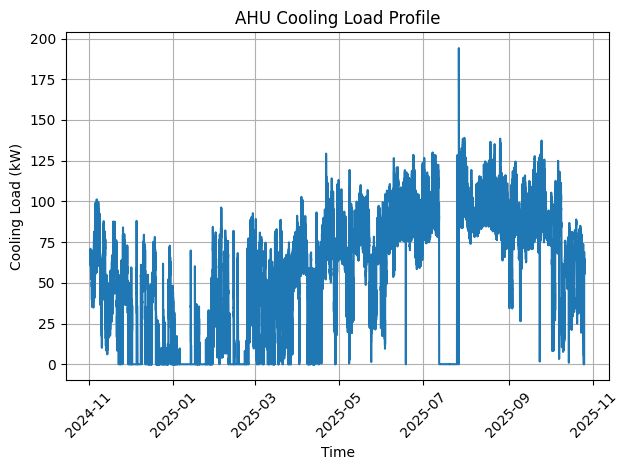

In [17]:
#visualization
plt.figure()
plt.plot(merged_df["timestamp"], merged_df["cooling_load_kw_thermal"])

plt.xlabel("Time")
plt.ylabel("Cooling Load (kW)")
plt.title("AHU Cooling Load Profile")

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

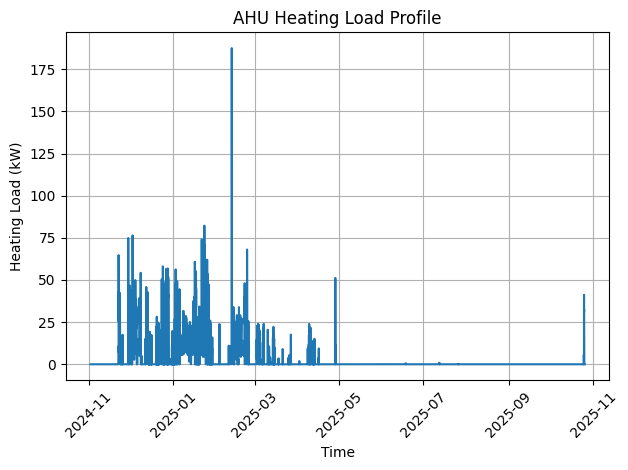

In [18]:
plt.figure()
plt.plot(merged_df["timestamp"], merged_df["heating_load_kw_thermal"])

plt.xlabel("Time")
plt.ylabel("Heating Load (kW)")
plt.title("AHU Heating Load Profile")

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
#Total Energy Demand Calculation
merged_df["cooling_energy_kwh_thermal"] = merged_df["cooling_load_kw_thermal"] * 0.25
total_energy = merged_df["cooling_energy_kwh_thermal"].sum()
print("Total Cooling Energy (kWh thermal):", total_energy)

Total Cooling Energy (kWh thermal): 1887081.8442644246


In [20]:
#Daily Energy Demand Calculation
merged_df["date"] = merged_df["timestamp"].dt.date
daily_energy = merged_df.groupby("date")["cooling_energy_kwh_thermal"].sum()
daily_energy

,cooling_energy_kwh_thermal
date,
2024-11-01,6.653482e+01
2024-11-02,1.477319e+03
2024-11-03,1.429144e+06
2024-11-04,1.340183e+03
2024-11-05,1.565742e+03
...,...
2025-10-21,1.355484e+03
2025-10-22,1.508586e+03
2025-10-23,1.260245e+03


### (2) Physics-based equation model: Fan Energy (Estimated)
Fan power is estimated using fan affinity laws:
\\[P \propto (\frac{speed}{100})^3\\]

where, P is fan power and speed is fan speed(%).

In [21]:
design_cfm = merged_df["SA_CFM"].max()
design_power_kw = 7.36 ### please add your fan power input

merged_df["fan_power_kw_est"] = design_power_kw * (merged_df["SA_CFM"] / design_cfm) ** 3
merged_df["fan_energy_kwh"] = merged_df["fan_power_kw_est"] * 0.25

In [22]:
total_fan_energy = merged_df["fan_energy_kwh"].sum()
print("Total Fan Energy (kWh):", total_fan_energy)

Total Fan Energy (kWh): 64371.78917983083


In [23]:
fan_speed_cols = [
    "SF1_speed",
    "SF2_speed",
    "SF3_speed",
    "SF4_speed",
    "SF5_speed",
    "SF6_speed",
]

rated_bhp = 7.36
rated_kw_shaft = rated_bhp * 0.7457
motor_eff = 0.90
rated_kw_elec = rated_kw_shaft / motor_eff

print("Rated shaft power per fan (kW):", rated_kw_shaft)
print("Rated electric power per fan (kW):", rated_kw_elec)

for col in fan_speed_cols:
    power_col = col + "_power_kw_est"
    merged_df[power_col] = rated_kw_elec * (merged_df[col] / 100.0) ** 3

Rated shaft power per fan (kW): 5.488352000000001
Rated electric power per fan (kW): 6.09816888888889


In [24]:
fan_power_cols = [col + "_power_kw_est" for col in fan_speed_cols]
merged_df["total_fan_power_kw_est"] = merged_df[fan_power_cols].sum(axis=1)
merged_df["total_fan_energy_kwh_est"] = merged_df["total_fan_power_kw_est"] * 0.25

merged_df[["timestamp"] + fan_speed_cols + ["total_fan_power_kw_est", "total_fan_energy_kwh_est"]].head()

,timestamp,SF1_speed,SF2_speed,SF3_speed,SF4_speed,SF5_speed,SF6_speed,total_fan_power_kw_est,total_fan_energy_kwh_est
0,2024-11-01 23:01:13,50.996346,50.996346,50.996346,50.996346,50.996346,50.996346,4.852526,1.213131
1,2024-11-01 23:16:13,49.974602,49.974602,49.974602,49.974602,49.974602,49.974602,4.566660,1.141665
2,2024-11-01 23:31:13,47.374275,47.374275,47.374275,47.374275,47.374275,47.374275,3.890258,0.972565
3,2024-11-01 23:46:13,52.612144,52.612144,52.612144,52.612144,52.612144,52.612144,5.328546,1.332136
4,2024-11-02 00:01:13,48.546005,48.546005,48.546005,48.546005,48.546005,48.546005,4.186115,1.046529


In [25]:
print("Total Estimated Fan Energy (kWh):", merged_df["total_fan_energy_kwh_est"].sum())

Total Estimated Fan Energy (kWh): 195307.11485901452


In [26]:
merged_df["date"] = merged_df["timestamp"].dt.date
daily_fan_energy = merged_df.groupby("date")["total_fan_energy_kwh_est"].sum()
daily_fan_energy

,total_fan_energy_kwh_est
date,
2024-11-01,4.659498
2024-11-02,106.758018
2024-11-03,138079.953720
2024-11-04,121.744798
2024-11-05,132.923395
...,...
2025-10-21,164.128036
2025-10-22,166.320239
2025-10-23,170.187535


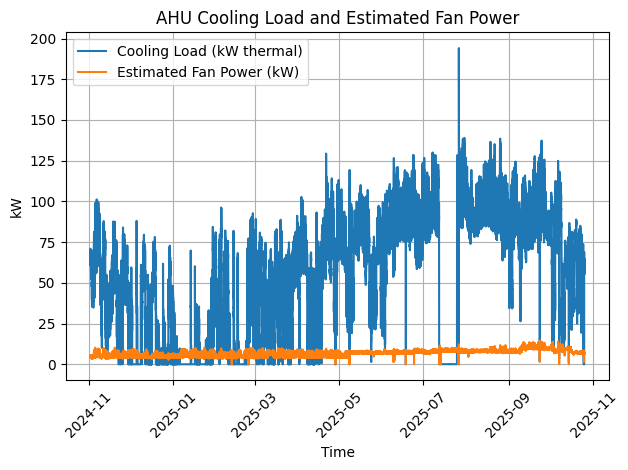

In [27]:
plt.figure()
plt.plot(merged_df["timestamp"], merged_df["cooling_load_kw_thermal"], label="Cooling Load (kW thermal)")
plt.plot(merged_df["timestamp"], merged_df["total_fan_power_kw_est"], label="Estimated Fan Power (kW)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.title("AHU Cooling Load and Estimated Fan Power")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Layer 2. Prompt Builder
Organize the calculated results into a structure that can be understood by an LLM. Python code computes physics-based operational indicators from BAS data. An OpenAI API-based LLM then interprets the operational status, generates reports, and answers questions based on these results.

In [28]:
def build_interval_summary(row): #generate summary for LLM
    return {
        "timestamp": str(row["timestamp"]),
        "mode": row["mode"],
        "mixed_air_temp_f": round(float(row["MA_T"]), 2),
        "supply_air_temp_f": round(float(row["SA_T"]), 2),
        "return_air_temp_f": round(float(row["RA_T"]), 2) if pd.notna(row["RA_T"]) else None,
        "outdoor_air_temp_f": round(float(row["OA_T"]), 2) if pd.notna(row["OA_T"]) else None,
        "supply_airflow_cfm": round(float(row["SA_CFM"]), 2),
        "outdoor_airflow_cfm": round(float(row["OA_CFM"]), 2) if pd.notna(row["OA_CFM"]) else None,
        "cooling_load_btuh": round(float(row["cooling_load_btuh"]), 2),
        "cooling_load_kw_thermal": round(float(row["cooling_load_kw_thermal"]), 2),
        "cooling_energy_kwh_thermal": round(float(row["cooling_energy_kwh_thermal"]), 2),
        "total_fan_power_kw_est": round(float(row["total_fan_power_kw_est"]), 2),
        "total_fan_energy_kwh_est": round(float(row["total_fan_energy_kwh_est"]), 2),
    }

In [29]:
sample_summary = build_interval_summary(merged_df.iloc[0])
sample_summary

{'timestamp': '2024-11-01 23:01:13',
 'mode': 'cooling',
 'mixed_air_temp_f': 69.92,
 'supply_air_temp_f': 54.89,
 'return_air_temp_f': 71.49,
 'outdoor_air_temp_f': 65.86,
 'supply_airflow_cfm': 14409.62,
 'outdoor_airflow_cfm': 5297.5,
 'cooling_load_btuh': 233795.41,
 'cooling_load_kw_thermal': 68.52,
 'cooling_energy_kwh_thermal': 17.13,
 'total_fan_power_kw_est': 4.85,
 'total_fan_energy_kwh_est': 1.21}

In [30]:
def build_prompt(summary):
    return f"""
You are an HVAC operational analysis assistant.

Analyze the AHU operation summary below and provide a concise diagnostic report.

AHU operation summary:
- Timestamp: {summary['timestamp']}
- Operating mode: {summary['mode']}
- Mixed air temperature: {summary['mixed_air_temp_f']} F
- Supply air temperature: {summary['supply_air_temp_f']} F
- Return air temperature: {summary['return_air_temp_f']} F
- Outdoor air temperature: {summary['outdoor_air_temp_f']} F
- Supply airflow: {summary['supply_airflow_cfm']} CFM
- Outdoor airflow: {summary['outdoor_airflow_cfm']} CFM
- Cooling load: {summary['cooling_load_btuh']} Btu/h
- Cooling load (thermal): {summary['cooling_load_kw_thermal']} kW
- Cooling energy during this interval: {summary['cooling_energy_kwh_thermal']} kWh
- Estimated total fan power: {summary['total_fan_power_kw_est']} kW
- Estimated total fan energy during this interval: {summary['total_fan_energy_kwh_est']} kWh

Please provide:
1. A short operational summary
2. Interpretation of cooling demand
3. Interpretation of fan power
4. Whether the AHU appears to be operating normally
5. One recommended action

Keep the response concise and engineering-focused.
""".strip()

In [33]:
api_key = os.getenv("OPENAI_API_KEY") #connect with LLM (I used OpenAI API in this project)

In [35]:
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key: ··········


In [36]:
# Call OpenAI API

from openai import OpenAI

client = OpenAI()

prompt = build_prompt(sample_summary)

response = client.responses.create(
    model="gpt-5",
    input=prompt
)

print(response.output_text)

1) Operational summary
- Cooling mode, SAT 54.9 F with 14.4 kcfm supply.
- OA flow 5.30 kcfm (~37% OA). OAT 65.9 F, RAT 71.5 F, MAT 69.9 F (mixing aligns with OA fraction).
- Coil ∆T (MAT→SAT) ≈ 15.0 F; sensible cooling ≈ 233.8 kBtu/h (~19.5 tons, 68.5 kW).
- Interval energy (15 min): cooling 17.1 kWh; fan 1.21 kWh.

2) Cooling demand interpretation
- Moderate mechanical cooling for late evening conditions; OAT < RAT but > SAT, so economizer alone can’t meet 55 F SAT.
- With current OA fraction, MAT is near return temp; moving toward 100% OA would drop MAT to ~65.9 F, cutting coil load by ~62 kBtu/h (~27%) while still needing some mechanical cooling.

3) Fan power interpretation
- Estimated fan power 4.85 kW → ~0.34 kW/kcfm (0.34 W/CFM), which is efficient and consistent with the airflow; no fan power anomaly indicated.

4) Operational status
- Appears normal: temperatures are self-consistent with airflow and load; energy aligns with a 15‑minute interval; mixing calc checks out. Opport

In [37]:
reports = [] #create a report

for i in range(5):
    row = merged_df.iloc[i]
    summary = build_interval_summary(row)
    prompt = build_prompt(summary)

    response = client.responses.create(
        model="gpt-5",
        input=prompt
    )

    reports.append({
        "timestamp": summary["timestamp"],
        "mode": summary["mode"],
        "cooling_load_kw_thermal": summary["cooling_load_kw_thermal"],
        "total_fan_power_kw_est": summary["total_fan_power_kw_est"],
        "report": response.output_text
    })

reports_df = pd.DataFrame(reports)
reports_df.head()

,timestamp,mode,cooling_load_kw_thermal,total_fan_power_kw_est,report
0,2024-11-01 23:01:13,cooling,68.52,4.85,1) Operational summary\n- AHU in cooling at ni...
1,2024-11-01 23:16:13,cooling,64.91,4.57,1) Operational summary\n- Mode: Cooling at nig...
2,2024-11-01 23:31:13,cooling,61.79,3.89,1) Operational summary\n- Mode: Cooling; SAT 5...
3,2024-11-01 23:46:13,cooling,70.91,5.33,1) Operational summary\n- Mode: Cooling; SAT 5...
4,2024-11-02 00:01:13,cooling,63.09,4.19,1) Operational summary\n- AHU in cooling at ni...


In [38]:
reports_df
reports_df.to_csv("ahu_genai_reports.csv", index=False)